# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train_all= np.array(Train_Sample[VarNames[1:]])
y_Train= np.array(Train_Sample["signal"])
X_Test_all= np.array(Test_Sample[VarNames[1:]])
y_Test= np.array(Test_Sample["signal"])

X_Train_raw= np.array(Train_Sample[RawNames])
X_Test_raw= np.array(Test_Sample[RawNames])

# High-level engineered features only
X_Train_feat= np.array(Train_Sample[FeatureNames])
X_Test_feat= np.array(Test_Sample[FeatureNames])

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

2026-04-26 14:40:34.397761: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 14:40:34.414436: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 14:40:34.626145: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 14:40:34.628486: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-26 14:40:36.121764: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

TensorFlow version: 2.13.1


In [4]:

# Standardise each input set
def scale(X_tr, X_te):
    sc= StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_te)

X_Train_all_s,  X_Test_all_s= scale(X_Train_all,  X_Test_all)
X_Train_raw_s,  X_Test_raw_s= scale(X_Train_raw,  X_Test_raw)
X_Train_feat_s, X_Test_feat_s= scale(X_Train_feat, X_Test_feat)

print("Train size:", X_Train_all_s.shape, " | Test size:", X_Test_all_s.shape)

Train size: (500000, 18)  | Test size: (50000, 18)


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [5]:
def plot_history(history, title="Model Training History"):
    # Create a canvas grid with two side-by-side subplots to display loss and accuracy separately.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss over epochs
    #Training loss measures how good model is fitting with training data
    # Validation loss measures generalization to unseen data
    ax = axes[0]
    ax.plot(history.history['loss'],     label='Train loss',      linewidth=2)
    ax.plot(history.history['val_loss'], label='Validation loss', linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Cross-Entropy Loss')
    ax.set_title('Loss vs Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Accuracy over epochs
    #Training accuracy for performance on training set of data
    #Validation accuracy for performance on held-out set of data
    
    ax = axes[1]
    ax.plot(history.history['accuracy'],     label='Train accuracy',      linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Validation accuracy', linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # extract the total number of epochs the model was trained for and display it
    final_epoch = len(history.history['loss'])
    print(f"Epochs trained: {final_epoch}")
    
    #Display final training and validation metrices at the last epoch
    print(f"Final train     loss={history.history['loss'][-1]:.4f},  acc={history.history['accuracy'][-1]:.4f}")
    print(f"Final val       loss={history.history['val_loss'][-1]:.4f},  acc={history.history['val_accuracy'][-1]:.4f}")

    # Compute a gap between validation loss and training loss as a proxy for overfitting: positive gap indicating model performance is worse on unseen data
    gap = history.history['val_loss'][-1] - history.history['loss'][-1]
    if gap > 0.02:
        print(f"Possible over-training detected (val_loss - train_loss = {gap:.4f})")
    else:
        print(f"No significant over-training (val_loss - train_loss = {gap:.4f})")

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

Training on RAW (low-level) features


2026-04-26 14:40:37.941819: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 14:40:37.974605: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


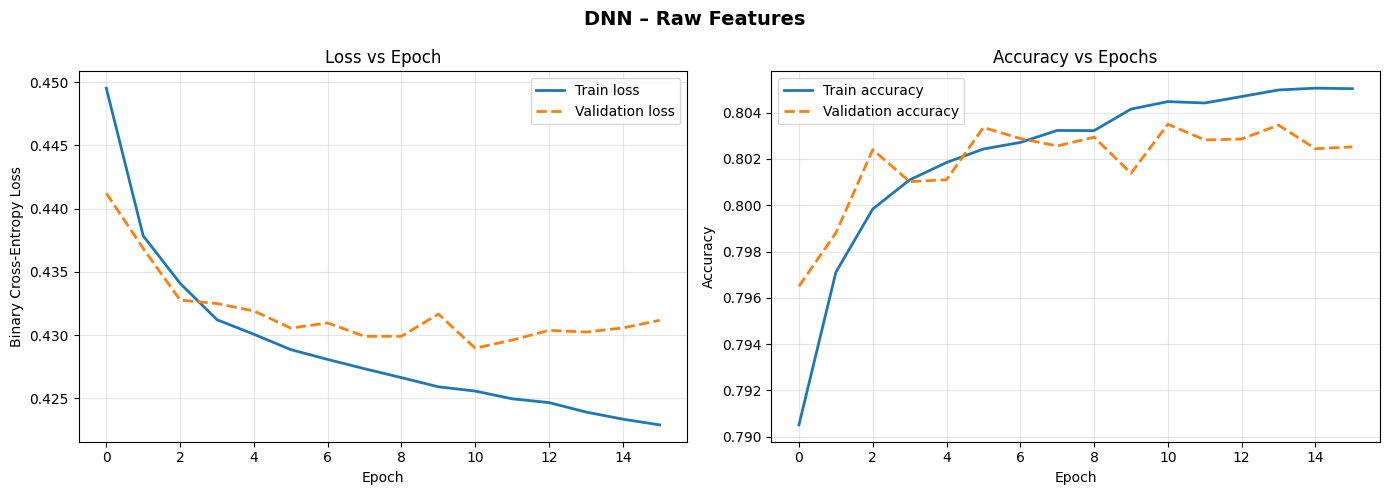

Epochs trained: 16
Final train     loss=0.4229,  acc=0.8050
Final val       loss=0.4312,  acc=0.8025
No significant over-training (val_loss - train_loss = 0.0083)
Training on HIGH-LEVEL (engineered) features
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


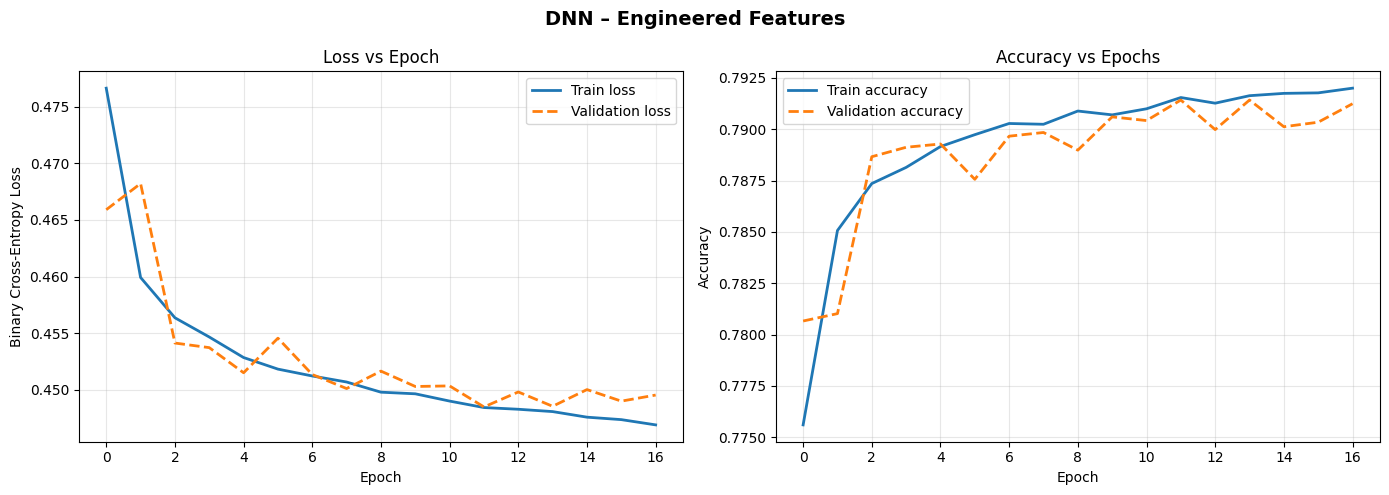

Epochs trained: 17
Final train     loss=0.4469,  acc=0.7920
Final val       loss=0.4495,  acc=0.7912
No significant over-training (val_loss - train_loss = 0.0026)
Training on ALL features (Raw + Engineered)
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


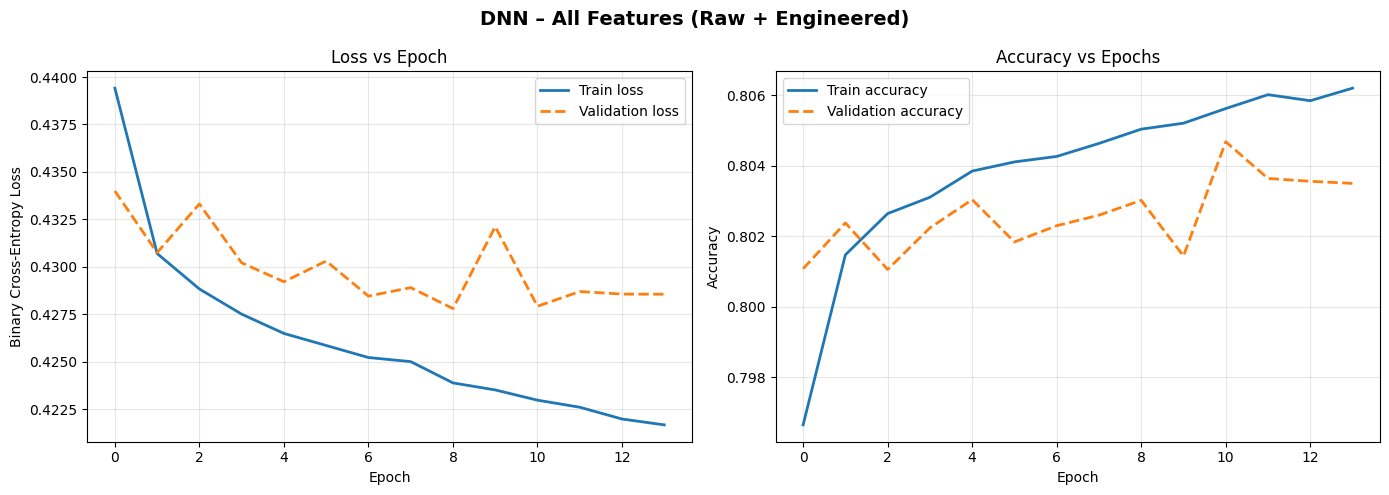

Epochs trained: 14
Final train     loss=0.4217,  acc=0.8062
Final val       loss=0.4286,  acc=0.8035
No significant over-training (val_loss - train_loss = 0.0069)


In [6]:
def build_baseline_dnn(input_dim, name="DNN"):
    #Simple 3-hidden-layer DNN baseline.
    
    #Create a sequential model consisting of three hidden layers, each with 300 neurons and ReLU activation
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name='input'),
        layers.Dense(300, activation='relu'),
        layers.Dense(300, activation='relu'),
        layers.Dense(300, activation='relu'),
        layers.Dense(1,   activation='sigmoid', name='output'),
    ], name=name)
    
    #Compile the model using the Adam optimizer: for adaptation of learning rate, Binary cross-entroy as loss function, and Accuracy as secondary metric alongside loss
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Define an EarlyStopping callback to halt training if validation loss does not improve for 5 consecutive epochs.
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Training for Raw features
# Train the baseline DNN on the raw feature set to establish a performance reference.
# The input dimension is inferred from the scaled training matrix at runtime.
# 10% of the training data is held out as a validation split to monitor generalization.
# A batch size of 1024 is used to balance gradient stability with computational throughput.
print("=" * 50)
print("Training on RAW (low-level) features")
model_raw = build_baseline_dnn(X_Train_raw_s.shape[1], name="DNN_Raw")
hist_raw = model_raw.fit(
    X_Train_raw_s, y_Train,
    epochs=50, batch_size=1024,
    validation_split=0.1,
    callbacks=[es], verbose=0
)
plot_history(hist_raw, "DNN – Raw Features")



# Training for Engineered features
# Train an equivalent DNN on the manually engineered feature set.
# This experiment isolates the contribution of domain-specific feature engineering
# to model performance, independent of architectural differences.
print("=" * 50)
print("Training on HIGH-LEVEL (engineered) features")
model_feat = build_baseline_dnn(X_Train_feat_s.shape[1], name="DNN_Features")
hist_feat = model_feat.fit(
    X_Train_feat_s, y_Train,
    epochs=50, batch_size=1024,
    validation_split=0.1,
    callbacks=[es], verbose=0
)
plot_history(hist_feat, "DNN – Engineered Features")



# Training for All features (Raw+Engineered)
# Train the DNN on the concatenated feature matrix combining both raw and engineered features.
# This condition tests whether the model benefits from the complementary information
# provided by both representations, or whether redundancy negatively impacts performance.
print("=" * 50)
print("Training on ALL features (Raw + Engineered)")
model_all = build_baseline_dnn(X_Train_all_s.shape[1], name="DNN_All")
hist_all = model_all.fit(
    X_Train_all_s, y_Train,
    epochs=50, batch_size=1024,
    validation_split=0.1,
    callbacks=[es], verbose=0
)
plot_history(hist_all, "DNN – All Features (Raw + Engineered)")

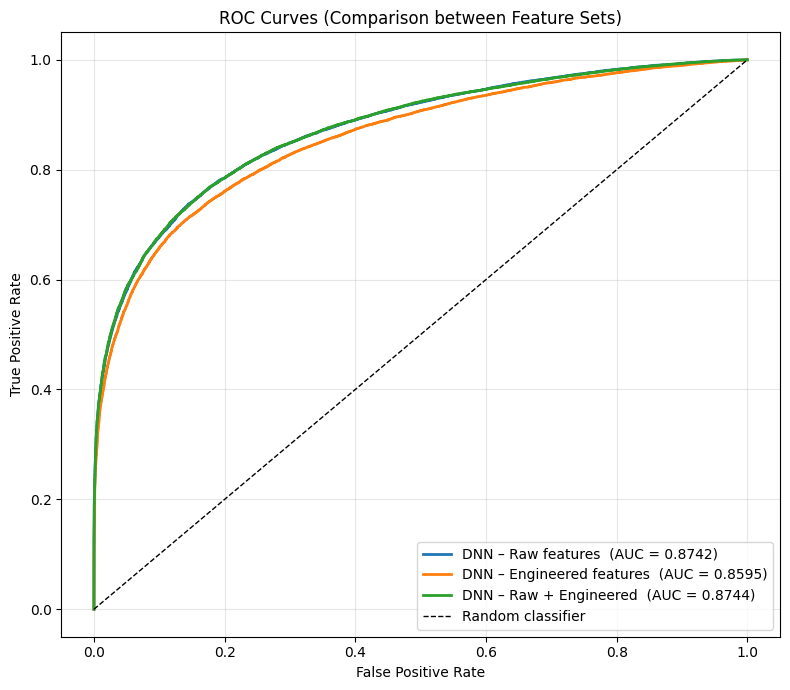

In [7]:
def plot_roc_curves(models_dict, title="ROC Curve Comparison"):
    #Plot ROC curves for multiple models. models_dict maps label -> (model, X_test, y_test).
    plt.figure(figsize=(8, 7))
    
    #Loop over each model entry in the dictionary. Then for each model generate predicted probability score (test set) and compute ROC curve with AUC metric
    for label, (model, X_te, y_te) in models_dict.items():
        y_score = model.predict(X_te, verbose=0).ravel()
        fpr, tpr, _ = roc_curve(y_te, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{label}  (AUC = {roc_auc:.4f})")

    
     # Plot the diagonal reference line representing a random classifier (AUC = 0.5).
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Compare all feature combinations. Format "DNN- Feature_Combination": (model_name, x_test(for corresponding combination), y_test)
ex2_models = {
    "DNN – Raw features"        : (model_raw,  X_Test_raw_s,  y_Test),
    "DNN – Engineered features" : (model_feat, X_Test_feat_s, y_Test),
    "DNN – Raw + Engineered"    : (model_all,  X_Test_all_s,  y_Test),
}
plot_roc_curves(ex2_models, title="ROC Curves (Comparison between Feature Sets)")

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

We try **three** architectures that vary depth, width, regularisation, and optimiser:

| Model | Architecture | Regularisation | Optimiser |
|-------|-------------|----------------|-----------|
| A – Shallow wide | 2 × 512 | None | Adam |
| B – Deep narrow | 5 × 128 | None | Adam |
| C – Deep + Dropout | 4 × 256 + Dropout(0.3) | Dropout | Adam |


Training model A – Shallow Wide
Model: "A_Shallow_Wide"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 512)               9728      
                                                                 
 dense_10 (Dense)            (None, 512)               262656    
                                                                 
 dense_11 (Dense)            (None, 1)                 513       
                                                                 
Total params: 272897 (1.04 MB)
Trainable params: 272897 (1.04 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


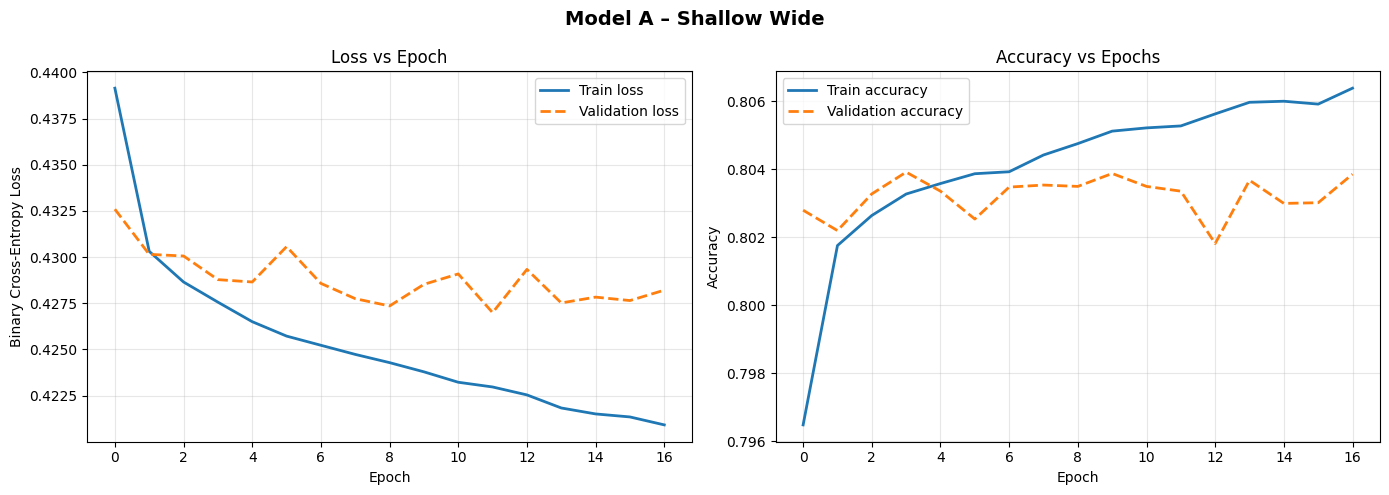

Epochs trained: 17
Final train     loss=0.4209,  acc=0.8064
Final val       loss=0.4282,  acc=0.8039
No significant over-training (val_loss - train_loss = 0.0073)

Training model B – Deep Narrow
Model: "B_Deep_Narrow"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 128)               2432      
                                                                 
 dense_13 (Dense)            (None, 128)               16512     
                                                                 
 dense_14 (Dense)            (None, 128)               16512     
                                                                 
 dense_15 (Dense)            (None, 128)               16512     
                                                                 
 dense_16 (Dense)            (None, 128)               16512     
                                                        

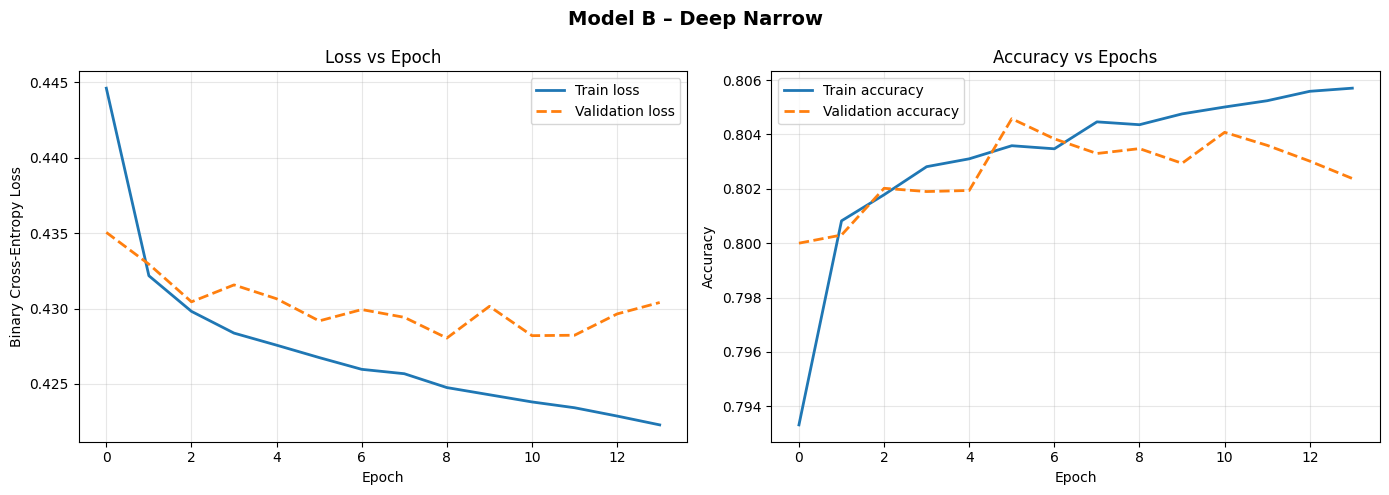

Epochs trained: 14
Final train     loss=0.4223,  acc=0.8057
Final val       loss=0.4304,  acc=0.8024
No significant over-training (val_loss - train_loss = 0.0081)

Training model C – Deep Dropout
Model: "C_Deep_Dropout"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 256)               4864      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_19 (Dense)            (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_20 (Dense)            (None, 256)               65792     
                                                      

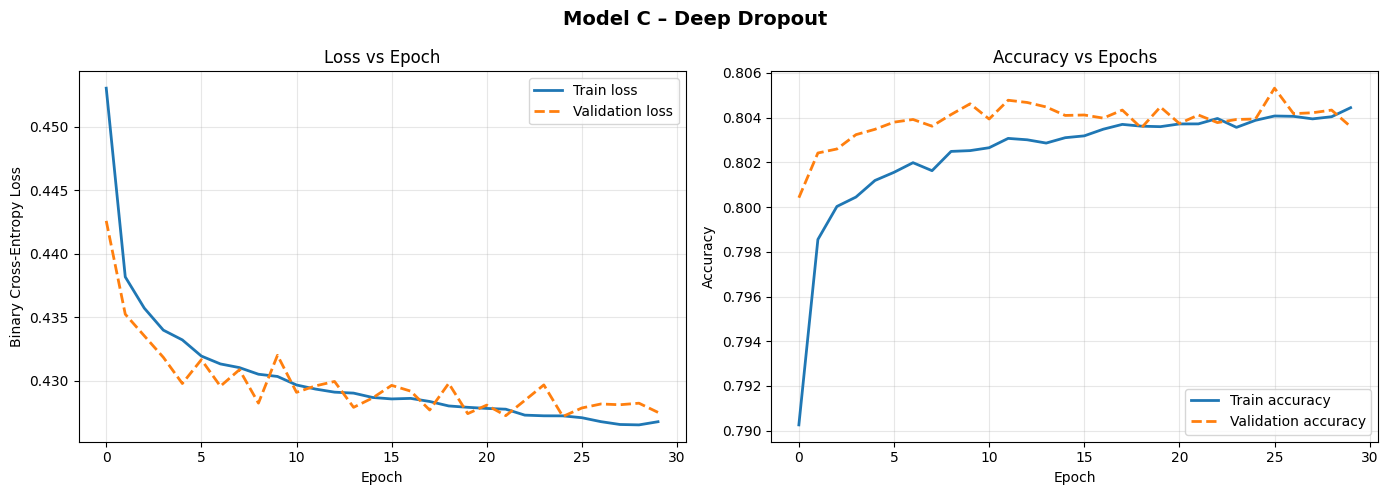

Epochs trained: 30
Final train     loss=0.4268,  acc=0.8044
Final val       loss=0.4275,  acc=0.8036
No significant over-training (val_loss - train_loss = 0.0007)


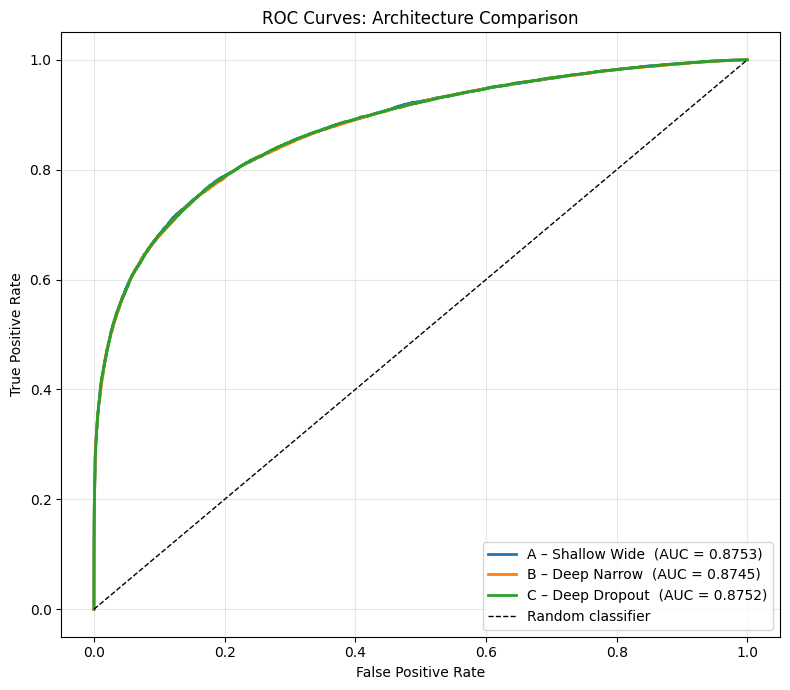

In [9]:
# Determine the input dimensionality from the full feature matrix (raw + engineered)
input_dim = X_Train_all_s.shape[1]  # use all features for architecture comparison

# Model A: Shallow & Wide
# This architecture uses two hidden layers with a large number of units (512) per layer.
# Width allows the network to learn a broad set of feature interactions in fewer
# compositional steps, at the cost of a higher parameter count per layer.
def build_model_A(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name="A_Shallow_Wide")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

#  Model B: Deep & Narrow
# This architecture increases depth to five hidden layers while reducing width to 128
# units per layer. Greater depth enables the network to learn increasingly abstract
# hierarchical representations, though it also introduces a higher risk of vanishing
# gradients and longer convergence times compared to shallower configurations.
def build_model_B(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name="B_Deep_Narrow")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model C: Deep + Dropout
# This architecture augments a four-layer deep network with Dropout regularisation
# after each of the first three hidden layers. At each training step, Dropout randomly
# deactivates 30% of neurons, which discourages co-adaptation and acts as an implicit
# ensemble method, improving generalization to unseen data. Dropout is omitted before
# the output layer to preserve stable probability estimates at inference time
def build_model_C(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name="C_Deep_Dropout")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# EarlyStopping callback for the experiment
# Training halts if validation loss fails to improve for 5 consecutive epochs, and the weights from the best-performing epoch are restored automatically.
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)


#Defining  et of architectures to be evaluated: each as (label, builder) pair.
architecture_configs = [
    ("A – Shallow Wide",  build_model_A),
    ("B – Deep Narrow",   build_model_B),
    ("C – Deep Dropout",  build_model_C)
]


#Iterate over each architecture, initialize model, print its structure summary, and traind under identical conditions
trained_models = {}
for label, builder in architecture_configs:
    print(f"\n{'='*55}")
    print(f"Training model {label}")
    m = builder(input_dim)
    m.summary()
    hist = m.fit(
        X_Train_all_s, y_Train,
        epochs=50, batch_size=1024,
        validation_split=0.1,
        callbacks=[es], verbose=0
    )
    plot_history(hist, f"Model {label}")
    
    # Each trained model is stored in trained_models alongside its test partition, so all four can be passed to plot_roc_curves for a unified evaluation.
    trained_models[label] = (m, X_Test_all_s, y_Test)

#Plot ROC curve for all four architectures
plot_roc_curves(trained_models, "ROC Curves: Architecture Comparison")

In [10]:
#Identify the best DNN (highest AUC)
from sklearn.metrics import roc_auc_score

# Predict on the test set for each model and record its AUC score.
auc_scores = {}
for label, (model, X_te, y_te) in trained_models.items():
    y_score = model.predict(X_te, verbose=0).ravel()
    auc_scores[label] = roc_auc_score(y_te, y_score)
    print(f"{label:30s}  AUC = {auc_scores[label]:.4f}")

#Select best model, one with highest AUC, as the best-performing architecture
best_label = max(auc_scores, key=auc_scores.get)
best_model, best_X_test, _ = trained_models[best_label]

#Print out the found result with its AUC score
print(f"\nBest DNN: {best_label}  (AUC = {auc_scores[best_label]:.4f})")

A – Shallow Wide                AUC = 0.8753
B – Deep Narrow                 AUC = 0.8745
C – Deep Dropout                AUC = 0.8752

Best DNN: A – Shallow Wide  (AUC = 0.8753)


## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


We add the best DNN from Exercise 3 to the traditional ML models from Lab 8 (BDT / Random Forest / etc.) and compare everything on a single ROC plot.

In [11]:
from sklearn.naive_bayes import GaussianNB     #Import GaussianNB
from sklearn.linear_model import LogisticRegression    #Import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier    #Import HistGradientBoostingClassifier

# Use the full all-features set for a fair comparison
X_sk_train = X_Train_all_s
y_sk_train = y_Train


#Defining the three models used in LAB 8 Exercise 4
sklearn_models = {
    'NB_Model': GaussianNB(),   # Naive Bayes Model
    'LR_Model': LogisticRegression(max_iter=1000, random_state=42),    # Linear model
    'Boost_Model': HistGradientBoostingClassifier(random_state=42)    #GradientBoost Model
}

ex4_models = {}  # will collect everything for final ROC plot

for name, clf in sklearn_models.items():
    print(f"Training {name}...", end=" ")
    clf.fit(X_sk_train, y_sk_train)
    y_score = clf.predict_proba(X_Test_all_s)[:, 1]
    roc_auc = roc_auc_score(y_Test, y_score)
    print(f"AUC = {roc_auc:.4f}")
    ex4_models[name] = (clf, X_Test_all_s, y_Test, y_score)

# Add best DNN
dnn_score = best_model.predict(best_X_test, verbose=0).ravel()
dnn_auc   = roc_auc_score(y_Test, dnn_score)
print(f"Best DNN ({best_label}) AUC = {dnn_auc:.4f}")
ex4_models[f"Best DNN ({best_label})"] = (None, None, y_Test, dnn_score)

Training NB_Model... AUC = 0.8113
Training LR_Model... AUC = 0.8565
Training Boost_Model... AUC = 0.8741
Best DNN (A – Shallow Wide) AUC = 0.8753


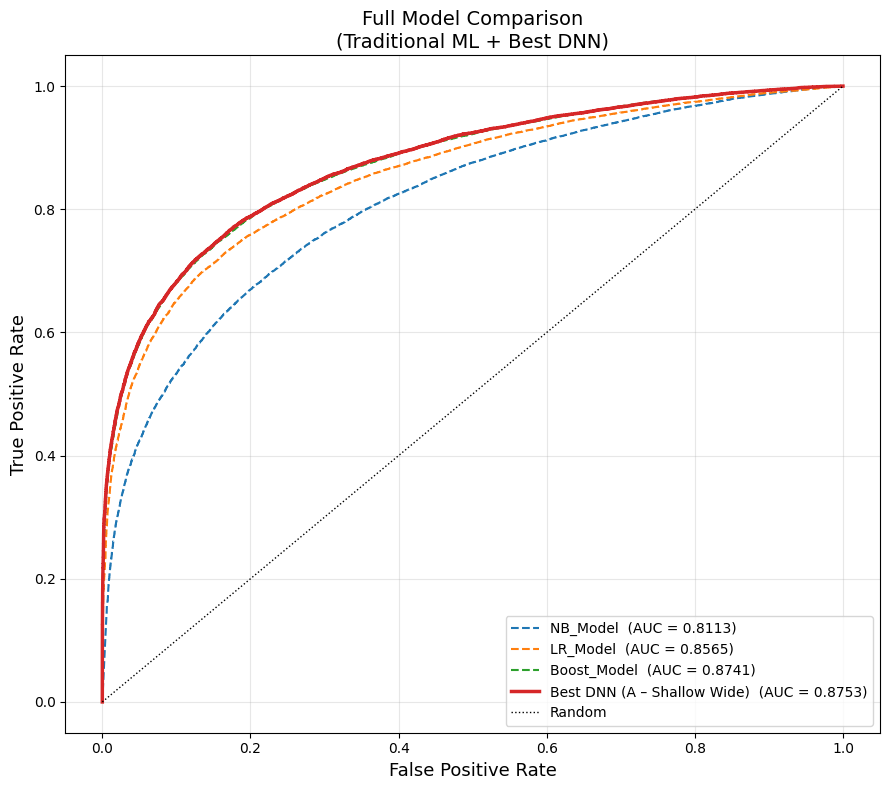


=== AUC Summary ===
Model                                    AUC
---------------------------------------------
NB_Model                              0.8113
LR_Model                              0.8565
Boost_Model                           0.8741
Best DNN (A – Shallow Wide)           0.8753


In [12]:
#Final ROC comparison plot

#Plot ROC curves for all classical models and best DNN (single plot)
#NOTE: Dashed lines are for classical ML algorithms and smooth line is for DNN

plt.figure(figsize=(9, 8))

for label, (_, __, y_te, y_score) in ex4_models.items():
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if "DNN" in label else 1.5
    ls = '-'  if "DNN" in label else '--'
    plt.plot(fpr, tpr, linewidth=lw, linestyle=ls,
             label=f"{label}  (AUC = {roc_auc:.4f})")

# Reference line for a random classifier (AUC = 0.5).
plt.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate',  fontsize=13)
plt.title('Full Model Comparison\n(Traditional ML + Best DNN)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
#Print a ranked AUC summary for all models
print("\n=== AUC Summary ===")
print(f"{'Model':<35} {'AUC':>8}")
print("-" * 45)
for label, (_, __, y_te, y_score) in ex4_models.items():
    print(f"{label:<35} {roc_auc_score(y_te, y_score):>8.4f}")

`NOTE`: AI was used for making codes effective and training Deep Neural Networks. 